### NVIDIA Stock Data Analysis

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Data Collection 
#### y finance API 5 ปีย้อนหลัง

In [10]:
ticker = "NVDA"
nvda = yf.Ticker(ticker)


df = nvda.history(period="5y")

df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None) 

print(f"จำนวนแถว: {df.shape[0]}, จำนวนคอลัมน์: {df.shape[1]}")
df.head()

จำนวนแถว: 1256, จำนวนคอลัมน์: 8


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-05-17,14.121408,14.133627,13.818672,14.129887,216980000,0.0,0.0
1,2021-05-18,14.231132,14.368037,13.968793,13.980514,186256000,0.0,0.0
2,2021-05-19,13.532394,14.044104,13.509202,14.030389,344000000,0.0,0.0
3,2021-05-20,14.266542,14.646834,14.234623,14.575763,321592000,0.0,0.0
4,2021-05-21,15.125625,15.183729,14.832115,14.954058,672992000,0.0,0.0


### Data Quality Control 

In [11]:
print("Missing Values Check")
print(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nData Types")
print(df.dtypes)

columns_to_keep = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df_clean = df[columns_to_keep].copy()
print("\nData Quality Control Completed. Data is ready for analysis.")

Missing Values Check
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Duplicate Rows: 0

Data Types
Date            datetime64[ns]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                   int64
Dividends              float64
Stock Splits           float64
dtype: object

Data Quality Control Completed. Data is ready for analysis.


### Data Storage System 

In [12]:
csv_filename = "NVDA_Historical_Data.csv"
df_clean.to_csv(csv_filename, index=False)
print(f"Saved data to {csv_filename}")

db_filename = "stock_data.db"
conn = sqlite3.connect(db_filename)
df_clean.to_sql("nvda_stock", conn, if_exists="replace", index=False)
conn.close()
print(f"Saved data to SQLite Database: {db_filename} (Table: nvda_stock)")

Saved data to NVDA_Historical_Data.csv
Saved data to SQLite Database: stock_data.db (Table: nvda_stock)


### Data Analysis & Statistics

Daily Return , Moving Average (MA) , Volatility เพื่อประเมินความเสี่ยง

In [13]:
display(df_clean.describe())

df_clean['Daily_Return'] = df_clean['Close'].pct_change() * 100

df_clean['MA50'] = df_clean['Close'].rolling(window=50).mean()
df_clean['MA200'] = df_clean['Close'].rolling(window=200).mean()

annual_volatility = df_clean['Daily_Return'].std() * np.sqrt(252)
print(f"\nAnnualized Volatility ความผันผวนต่อปี: {annual_volatility:.2f}%")

df_clean.tail()

,Date,Open,High,Low,Close,Volume
count,1256,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03
mean,2023-11-13 21:36:41.273885184,80.165723,81.493631,78.716330,80.170628,3.833835e+08
min,2021-05-17 00:00:00,10.956632,11.719631,10.798839,11.212297,6.552850e+07
25%,2022-08-14 06:00:00,22.228757,22.558064,21.804903,22.172005,2.202450e+08
50%,2023-11-11 12:00:00,47.458990,48.151966,46.534506,47.291534,3.704465e+08
75%,2025-02-13 06:00:00,134.828307,136.588171,132.132272,134.761982,5.006132e+08
max,2026-05-15 00:00:00,229.850006,236.539993,229.300003,235.740005,1.543911e+09
std,NaN,63.666051,64.534627,62.669951,63.633848,1.888084e+08



Annualized Volatility ความผันผวนต่อปี: 51.68%


,Date,Open,High,Low,Close,Volume,Daily_Return,MA50,MA200
1251,2026-05-11,214.039993,222.300003,213.889999,219.440002,160685800,1.970263,189.494620,184.945239
1252,2026-05-12,218.550003,223.750000,214.919998,220.779999,159176600,0.610644,190.260818,185.181783
1253,2026-05-13,224.929993,227.839996,221.570007,225.830002,150405400,2.287346,191.176613,185.427330
1254,2026-05-14,229.850006,236.539993,229.300003,235.740005,180782900,4.388258,192.230811,185.728626
1255,2026-05-15,229.759995,231.500000,224.240005,225.320007,179993300,-4.420123,193.070610,185.959025


### Data Visualization & Insights 

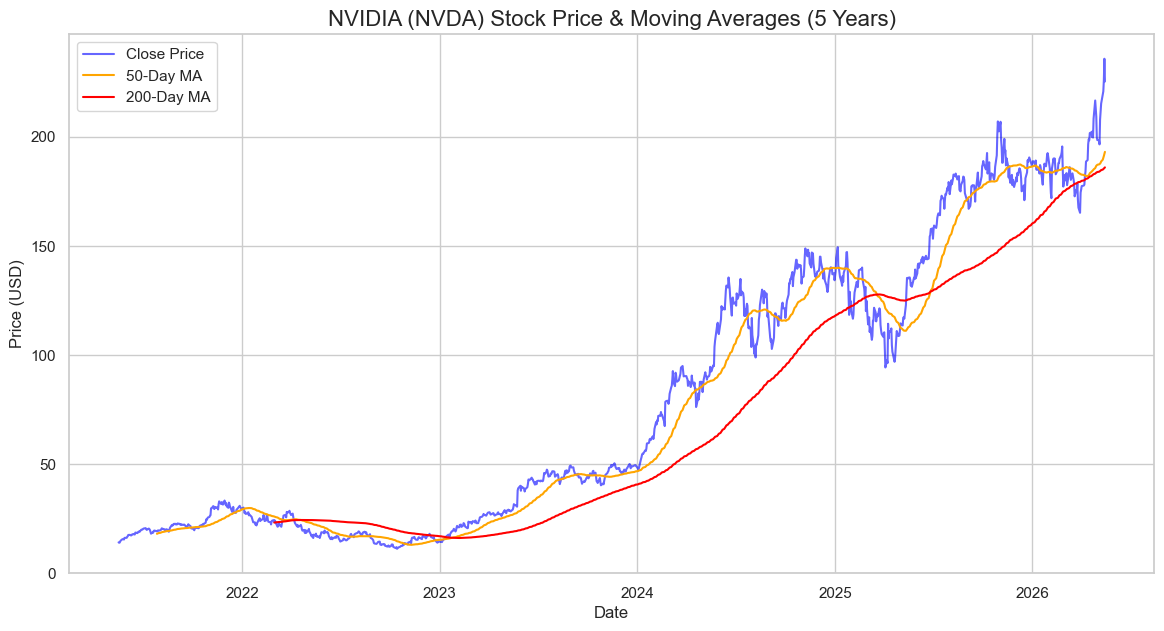

In [14]:
#Close Price And Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(df_clean['Date'], df_clean['Close'], label='Close Price', color='blue', alpha=0.6)
plt.plot(df_clean['Date'], df_clean['MA50'], label='50-Day MA', color='orange')
plt.plot(df_clean['Date'], df_clean['MA200'], label='200-Day MA', color='red')
plt.title('NVIDIA (NVDA) Stock Price & Moving Averages (5 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

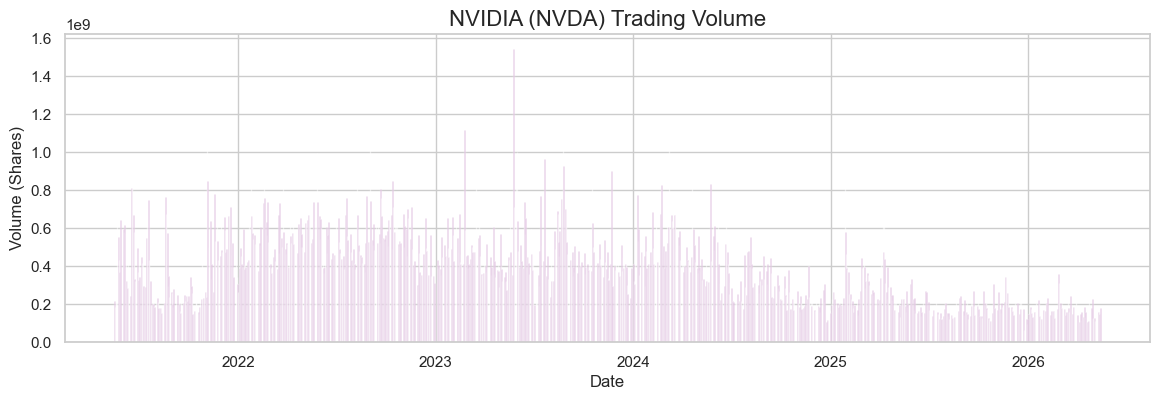

In [15]:
#Trading Volume
plt.figure(figsize=(14, 4))
plt.bar(df_clean['Date'], df_clean['Volume'], color='purple', alpha=0.5)
plt.title('NVIDIA (NVDA) Trading Volume', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume (Shares)')
plt.show()

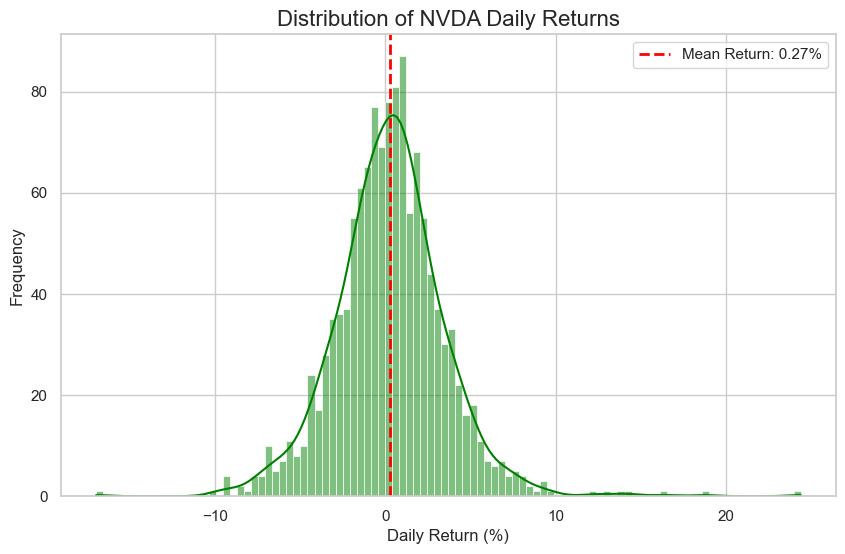

In [16]:
#Daily Return Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Daily_Return'].dropna(), bins=100, kde=True, color='green')
plt.title('Distribution of NVDA Daily Returns', fontsize=16)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

mean_return = df_clean['Daily_Return'].mean()
plt.axvline(mean_return, color='red', linestyle='dashed', linewidth=2, label=f'Mean Return: {mean_return:.2f}%')
plt.legend()
plt.show()